<a href="https://colab.research.google.com/github/ferdibudiutomo353-png/Tugas-Machine-Learning/blob/main/Implementasi_bab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementasi Python 3

Praktikum 3.1 – Persiapan Library

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report

Praktikum 3.2 – Import Dataset

In [2]:
# Dataset sintetis untuk simulasi
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=2000, n_features=8,
                           weights=[0.95, 0.05], random_state=42)
df = pd.DataFrame(X,
                  columns=[f"fitur_{i}" for i in range(8)])
df["target"] = y

# Simulasikan missing values
rng = np.random.default_rng(42)
mask = rng.random(df.shape) < 0.05
mask[:, -1] = False   # PERBAIKAN: kolom target jangan diberi missing
df_missing = df.mask(pd.DataFrame(mask, columns=df.columns))
print(df_missing.isnull().sum())

fitur_0    101
fitur_1     89
fitur_2     81
fitur_3    106
fitur_4    109
fitur_5     98
fitur_6    100
fitur_7     97
target       0
dtype: int64


Praktikum 3.3 – Preprocessing

In [3]:
# Imputasi dengan KNN Imputer (hanya pada kolom fitur)
imputer = KNNImputer(n_neighbors=5)
fitur_cols = [c for c in df.columns if c.startswith("fitur")]
df_imputed = df_missing.copy()
df_imputed[fitur_cols] = imputer.fit_transform(df_missing[fitur_cols])

# Deteksi outlier dengan Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
df_imputed["is_outlier"] = iso.fit_predict(df_imputed[fitur_cols])
print("Jumlah outlier terdeteksi:",
      (df_imputed["is_outlier"] == -1).sum())

Jumlah outlier terdeteksi: 40


Praktikum 3.4 – Training Model (dengan dan tanpa SMOTE)

In [4]:
X = df_imputed[fitur_cols]
y = df_imputed["target"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Tanpa penanganan imbalance
model_base = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Dengan SMOTE (HANYA pada train set)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000).fit(X_train_sm,
                                                    y_train_sm)

Praktikum 3.5 – Evaluasi

In [5]:
for nama, model in [("Baseline (tanpa SMOTE)", model_base),
                    ("Dengan SMOTE", model_smote)]:
    y_pred = model.predict(X_test)
    print(f"--- {nama} ---")
    print("Akurasi :", round(accuracy_score(y_test, y_pred), 3))
    print("F1-Score:", round(f1_score(y_test, y_pred), 3))

--- Baseline (tanpa SMOTE) ---
Akurasi : 0.953
F1-Score: 0.486
--- Dengan SMOTE ---
Akurasi : 0.88
F1-Score: 0.415


Praktikum 3.6 – Visualisasi

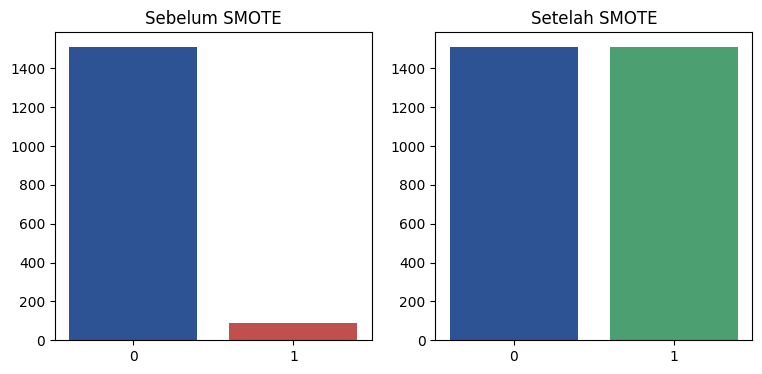

In [6]:
import matplotlib.pyplot as plt
before = y_train.value_counts(
after = pd.Series(y_train_sm).value_counts()
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(before.index.astype(str), before.values,
            color=["#2E5395", "#C0504D"])
axes[0].set_title("Sebelum SMOTE")
axes[1].bar(after.index.astype(str), after.values,
            color=["#2E5395", "#4C9F70"])
axes[1].set_title("Setelah SMOTE")
plt.show()